# **For Constant Temperature**
### From week 4 exercises

#### **Exact value with Interpolation**

In [3]:
# ============================================================
# BOLTZMANN SUPERPOSITION FOR N LOADS
# Constant temperature
# WITH FULL SHIFT FACTOR PRINTING
# ============================================================

import math
import pandas as pd

# ------------------------------------------------------------
# CREEP COMPLIANCE DATA TABLE
# Units: [1/Pa]
# ------------------------------------------------------------

data = {
    "TIME [hour]": [1, 10, 100, 1000, 10000, 100000],
    23: [2.5e-10, 2.6e-10, 2.7e-10, 3.0e-10, 4.0e-10, 6.5e-10],
    40: [3.0e-10, 3.6e-10, 4.5e-10, 6.3e-10, 9.7e-10, 1.6e-09],
    60: [4.6e-10, 6.4e-10, 9.8e-10, 1.6e-09, 2.9e-09, 5.5e-09],
}

df = pd.DataFrame(data)

# ============================================================
# WLF SHIFT FACTOR FUNCTION
# ============================================================

T_ref = 40  # Reference temperature [°C]

def shift_factor(T, T_ref):

    delta_T = T - T_ref

    log10_aT = (
        -(8.86 * delta_T)
        /
        (101.6 + delta_T)
    )

    aT = 10 ** log10_aT

    # --------------------------------------------------------
    # PRINT SHIFT FACTOR INFORMATION
    # --------------------------------------------------------

    print("------------------------------------------------")
    print(f"Reference temperature T_ref = {T_ref} °C")
    print(f"Current temperature T = {T} °C")
    print(f"ΔT = T - T_ref = {delta_T} °C")
    print(f"log10(aT) = {log10_aT:.6f}")
    print(f"aT = {aT:.6e}")
    print("------------------------------------------------\n")

    return aT

# ============================================================
# LOGARITHMIC INTERPOLATION FUNCTION
# ============================================================

def interpolate_compliance(t, temperature, df):

    time_values = df["TIME [hour]"].values
    J_values = df[temperature].values

    # Exact match
    if any(abs(t - tv) < 1e-9 for tv in time_values):

        idx = min(
            range(len(time_values)),
            key=lambda i: abs(time_values[i] - t)
        )

        return J_values[idx]

    # Find interval
    for i in range(len(time_values)-1):

        if time_values[i] <= t <= time_values[i+1]:

            t1 = time_values[i]
            t2 = time_values[i+1]

            J1 = J_values[i]
            J2 = J_values[i+1]

            # Logarithmic interpolation
            J_interp = (
                J1
                +
                (J2 - J1)
                *
                (
                    (math.log10(t) - math.log10(t1))
                    /
                    (math.log10(t2) - math.log10(t1))
                )
            )

            print(
                f"Interpolating between:"
                f" t1={t1}h and t2={t2}h"
            )

            print(
                f"J1={J1:.3e}, J2={J2:.3e}"
            )

            print(
                f"Interpolated J={J_interp:.3e}\n"
            )

            return J_interp

    raise ValueError("Time outside table range")

# ============================================================
# BOLTZMANN SUPERPOSITION FUNCTION
# ============================================================

def boltzmann_strain(
    sigma_changes,
    load_times,
    t_total,
    temperature,
    df
):

    epsilon = 0

    # --------------------------------------------------------
    # CALCULATE SHIFT FACTOR
    # --------------------------------------------------------

    aT = shift_factor(
        temperature,
        T_ref
    )

    # --------------------------------------------------------
    # CALCULATE STRAIN
    # --------------------------------------------------------

    for sigma, tau in zip(
        sigma_changes,
        load_times
    ):

        if t_total > tau:

            delta_t = t_total - tau

            print(
                f"Load contribution:"
            )

            print(
                f"σ = {sigma:.3e} Pa"
            )

            print(
                f"τ = {tau} h"
            )

            print(
                f"Δt = {delta_t} h"
            )

            J = interpolate_compliance(
                delta_t,
                temperature,
                df
            )

            contribution = sigma * J

            print(
                f"Contribution to strain = "
                f"{contribution:.6e}\n"
            )

            epsilon += contribution

    return epsilon

# ============================================================
# TYPE IN LOAD HISTORY !HERE!
# ============================================================

sigma_changes = [
    7e6,
    -7e6,
]

load_times = [
    0,
    10,
]

t_total = 11

temperature = 60

# ============================================================
# CALCULATE STRAIN
# ============================================================

epsilon = boltzmann_strain(
    sigma_changes,
    load_times,
    t_total,
    temperature,
    df
)

# ============================================================
# RESULTS
# ============================================================

print("================================================")
print("FINAL RESULTS")
print("================================================")

print(f"Total strain = {epsilon:.6e}")

print(
    f"Total strain percent = "
    f"{epsilon*100:.6f} %"
)

------------------------------------------------
Reference temperature T_ref = 40 °C
Current temperature T = 60 °C
ΔT = T - T_ref = 20 °C
log10(aT) = -1.457237
aT = 3.489500e-02
------------------------------------------------

Load contribution:
σ = 7.000e+06 Pa
τ = 0 h
Δt = 11 h
Interpolating between: t1=10h and t2=100h
J1=6.400e-10, J2=9.800e-10
Interpolated J=6.541e-10

Contribution to strain = 4.578515e-03

Load contribution:
σ = -7.000e+06 Pa
τ = 10 h
Δt = 1 h
Contribution to strain = -3.220000e-03

FINAL RESULTS
Total strain = 1.358515e-03
Total strain percent = 0.135851 %


In [2]:
# ============================================================
# BOLTZMANN SUPERPOSITION FOR N LOADS
# Constant temperature
# Uses creep compliance table with logarithmic interpolation
# ============================================================

import math
import pandas as pd

# ------------------------------------------------------------
# CREEP COMPLIANCE DATA TABLE
# Units: [1/Pa]
# ------------------------------------------------------------

data = {
    "TIME [hour]": [1, 10, 100, 1000, 10000, 100000],
    23: [2.5e-10, 2.6e-10, 2.7e-10, 3.0e-10, 4.0e-10, 6.5e-10],
    40: [3.0e-10, 3.6e-10, 4.5e-10, 6.3e-10, 9.7e-10, 1.6e-09],
    60: [4.6e-10, 6.4e-10, 9.8e-10, 1.6e-09, 2.9e-09, 5.5e-09],
}

df = pd.DataFrame(data)

# ============================================================
# LOGARITHMIC INTERPOLATION FUNCTION
# Returns J(t)
# ============================================================

def interpolate_compliance(t, temperature, df):

    time_values = df["TIME [hour]"].values
    J_values = df[temperature].values

    # Exact match
    if t in time_values:
        idx = list(time_values).index(t)
        return J_values[idx]

    # Find interval
    for i in range(len(time_values)-1):

        if time_values[i] <= t <= time_values[i+1]:

            t1 = time_values[i]
            t2 = time_values[i+1]

            J1 = J_values[i]
            J2 = J_values[i+1]

            # Logarithmic interpolation
            J_interp = (
                J1
                +
                (J2 - J1)
                *
                (
                    (math.log10(t) - math.log10(t1))
                    /
                    (math.log10(t2) - math.log10(t1))
                )
            )

            return J_interp

    raise ValueError("Time outside table range")

# ============================================================
# BOLTZMANN SUPERPOSITION FUNCTION
# ============================================================

def boltzmann_strain(
    sigma_changes,
    load_times,
    t_total,
    temperature,
    df
):

    epsilon = 0

    for sigma, tau in zip(sigma_changes, load_times):

        if t_total > tau:

            delta_t = t_total - tau

            J = interpolate_compliance(
                delta_t,
                temperature,
                df
            )

            epsilon += sigma * J

    return epsilon

# ============================================================
# TYPE IN LOAD HISTORY !HERE!
# ============================================================

# Stress changes [Pa]
sigma_changes = [
    7e6,     # Apply +7 MPa at t=0
    -7e6,    # Remove 7 MPa at t=10 h
]

# Times where stress changes occur [h]
load_times = [
    0,
    10,
]

# Total evaluation time [h]
t_total = 11

# Constant temperature [°C]
temperature = 60

# ============================================================
# CALCULATE STRAIN
# ============================================================

epsilon = boltzmann_strain(
    sigma_changes,
    load_times,
    t_total,
    temperature,
    df
)

# ============================================================
# RESULTS
# ============================================================

print("Strain =", epsilon)

print("Strain percent =", epsilon * 100, "%")

Strain = 0.0013585145906765757
Strain percent = 0.13585145906765758 %


#### **Approximate value without interpolation**

In [1]:
# ============================================================
# BOLTZMANN SUPERPOSITION FOR N LOADS
# WITHOUT INTERPOLATION
#
# Uses closest time match directly from the compliance table
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# CREEP COMPLIANCE DATA TABLE
# Units: [1/Pa]
# ------------------------------------------------------------

data = {
    "TIME [hour]": [1, 10, 100, 1000, 10000, 100000],
    23: [2.5e-10, 2.6e-10, 2.7e-10, 3.0e-10, 4.0e-10, 6.5e-10],
    40: [3.0e-10, 3.6e-10, 4.5e-10, 6.3e-10, 9.7e-10, 1.6e-09],
    60: [4.6e-10, 6.4e-10, 9.8e-10, 1.6e-09, 2.9e-09, 5.5e-09],
}

df = pd.DataFrame(data)

# ============================================================
# FIND CLOSEST TIME MATCH
# Returns closest J(t)
# ============================================================

def closest_compliance(t, temperature, df):

    time_values = df["TIME [hour]"].values

    # Find closest time value
    closest_time = min(
        time_values,
        key=lambda x: abs(x - t)
    )

    # Extract compliance value
    J = df.loc[
        df["TIME [hour]"] == closest_time,
        temperature
    ].iloc[0]

    print(
        f"Requested time = {t} h | "
        f"Closest table time = {closest_time} h"
    )

    return J

# ============================================================
# BOLTZMANN SUPERPOSITION FUNCTION
# ============================================================

def boltzmann_strain_closest(
    sigma_changes,
    load_times,
    t_total,
    temperature,
    df
):

    epsilon = 0

    for sigma, tau in zip(sigma_changes, load_times):

        if t_total > tau:

            delta_t = t_total - tau

            J = closest_compliance(
                delta_t,
                temperature,
                df
            )

            epsilon += sigma * J

    return epsilon

# ============================================================
# TYPE IN LOAD HISTORY !HERE!
# ============================================================

# Stress changes [Pa]
sigma_changes = [
    7e6,     # Apply +7 MPa at t=0
    -7e6,    # Remove 7 MPa at t=10 h
]

# Times where stress changes occur [h]
load_times = [
    0,
    10,
]

# Total evaluation time [h]
t_total = 11

# Constant temperature [°C]
temperature = 60

# ============================================================
# CALCULATE STRAIN
# ============================================================

epsilon = boltzmann_strain_closest(
    sigma_changes,
    load_times,
    t_total,
    temperature,
    df
)

# ============================================================
# RESULTS
# ============================================================

print("Strain =", epsilon)

print("Strain percent =", epsilon * 100, "%")

Requested time = 11 h | Closest table time = 10 h
Requested time = 1 h | Closest table time = 1 h
Strain = 0.0012599999999999994
Strain percent = 0.12599999999999995 %


# **For Different Temperatures**
### From week 4 exercises

#### **Exact value with Interpolation**

In [4]:
# ============================================================
# BOLTZMANN SUPERPOSITION FOR N LOADS
# DIFFERENT TEMPERATURES
# WITH FULL PRINTING + LOG INTERPOLATION
# ============================================================

import math
import pandas as pd

# ------------------------------------------------------------
# CREEP COMPLIANCE DATA TABLE
# Units: [1/Pa]
# ------------------------------------------------------------

data = {
    "TIME [hour]": [1, 10, 100, 1000, 10000, 100000],
    23: [2.5e-10, 2.6e-10, 2.7e-10, 3.0e-10, 4.0e-10, 6.5e-10],
    40: [3.0e-10, 3.6e-10, 4.5e-10, 6.3e-10, 9.7e-10, 1.6e-09],
    60: [4.6e-10, 6.4e-10, 9.8e-10, 1.6e-09, 2.9e-09, 5.5e-09],
}

df = pd.DataFrame(data)

# ============================================================
# REFERENCE TEMPERATURE
# ============================================================

T_ref = 40  # °C

# ============================================================
# WLF SHIFT FACTOR FUNCTION
# ============================================================

def shift_factor(T, T_ref):

    delta_T = T - T_ref

    log10_aT = (
        -(8.86 * delta_T)
        /
        (101.6 + delta_T)
    )

    aT = 10 ** log10_aT

    return log10_aT, aT

# ============================================================
# LOGARITHMIC INTERPOLATION FUNCTION
# ============================================================

def interpolate_compliance(t, temperature, df):

    time_values = df["TIME [hour]"].values
    J_values = df[temperature].values

    # Exact match
    if any(abs(t - tv) < 1e-9 for tv in time_values):

        idx = min(
            range(len(time_values)),
            key=lambda i: abs(time_values[i] - t)
        )

        J_exact = J_values[idx]

        print("Exact table value used")
        print(f"Time = {t} h")
        print(f"Compliance = {J_exact:.3e}\n")

        return J_exact

    # --------------------------------------------------------
    # FIND INTERPOLATION REGION
    # --------------------------------------------------------

    for i in range(len(time_values)-1):

        if time_values[i] <= t <= time_values[i+1]:

            t1 = time_values[i]
            t2 = time_values[i+1]

            J1 = J_values[i]
            J2 = J_values[i+1]

            log_t = math.log10(t)
            log_t1 = math.log10(t1)
            log_t2 = math.log10(t2)

            # ------------------------------------------------
            # LOG INTERPOLATION
            # ------------------------------------------------

            J_interp = (
                J1
                +
                (J2 - J1)
                *
                (
                    (log_t - log_t1)
                    /
                    (log_t2 - log_t1)
                )
            )

            # ------------------------------------------------
            # PRINT INTERPOLATION DETAILS
            # ------------------------------------------------

            print("Interpolation details:")
            print(f"Temperature = {temperature} °C")

            print(
                f"Interpolating between "
                f"{t1} h and {t2} h"
            )

            print(f"J1 = {J1:.3e}")
            print(f"J2 = {J2:.3e}")

            print(f"log10(t) = {log_t:.6f}")
            print(f"log10(t1) = {log_t1:.6f}")
            print(f"log10(t2) = {log_t2:.6f}")

            print(
                f"Interpolated J = "
                f"{J_interp:.3e}\n"
            )

            return J_interp

    raise ValueError(
        f"Time {t} h outside table range"
    )

# ============================================================
# BOLTZMANN SUPERPOSITION FUNCTION
# ============================================================

def boltzmann_strain_temperature(
    sigma_changes,
    load_times,
    temperatures,
    t_total,
    df
):

    epsilon = 0

    print("================================================")
    print("BOLTZMANN SUPERPOSITION CALCULATION")
    print("================================================\n")

    for sigma, tau, T in zip(
        sigma_changes,
        load_times,
        temperatures
    ):

        if t_total > tau:

            delta_t = t_total - tau

            # ------------------------------------------------
            # SHIFT FACTOR
            # ------------------------------------------------

            log10_aT, aT = shift_factor(
                T,
                T_ref
            )

            print("------------------------------------------------")
            print(f"Load event at t = {tau} h")

            print(f"Temperature T = {T} °C")
            print(f"Reference temperature = {T_ref} °C")

            print(
                f"ΔT = {T - T_ref} °C"
            )

            print(
                f"log10(aT) = {log10_aT:.6f}"
            )

            print(
                f"aT = {aT:.6e}"
            )

            print(
                f"Stress change σ = "
                f"{sigma:.3e} Pa"
            )

            print(
                f"Evaluation time difference Δt = "
                f"{delta_t} h\n"
            )

            # ------------------------------------------------
            # COMPLIANCE
            # ------------------------------------------------

            J = interpolate_compliance(
                delta_t,
                T,
                df
            )

            # ------------------------------------------------
            # STRAIN CONTRIBUTION
            # ------------------------------------------------

            contribution = sigma * J

            print(
                f"Strain contribution = "
                f"{contribution:.6e}"
            )

            print("------------------------------------------------\n")

            epsilon += contribution

    return epsilon

# ============================================================
# TYPE IN LOAD HISTORY !HERE!
# ============================================================

# Stress changes [Pa]
sigma_changes = [
    10e6,     # Apply +10 MPa
    -7e6,     # Remove 7 MPa
    -3e6,     # Remove remaining 3 MPa
]

# Times where stress changes occur [h]
load_times = [
    0,
    1,
    11,
]

# Temperature for EACH load event [°C]
temperatures = [
    60,
    23,
    40,
]

# Total evaluation time [h]
t_total = 12

# ============================================================
# CALCULATE STRAIN
# ============================================================

epsilon = boltzmann_strain_temperature(
    sigma_changes,
    load_times,
    temperatures,
    t_total,
    df
)

# ============================================================
# RESULTS
# ============================================================

print("================================================")
print("FINAL RESULTS")
print("================================================")

print(f"Total strain = {epsilon:.6e}")

print(
    f"Total strain percent = "
    f"{epsilon*100:.6f} %"
)

BOLTZMANN SUPERPOSITION CALCULATION

------------------------------------------------
Load event at t = 0 h
Temperature T = 60 °C
Reference temperature = 40 °C
ΔT = 20 °C
log10(aT) = -1.457237
aT = 3.489500e-02
Stress change σ = 1.000e+07 Pa
Evaluation time difference Δt = 12 h

Interpolation details:
Temperature = 60 °C
Interpolating between 10 h and 100 h
J1 = 6.400e-10
J2 = 9.800e-10
log10(t) = 1.079181
log10(t1) = 1.000000
log10(t2) = 2.000000
Interpolated J = 6.669e-10

Strain contribution = 6.669216e-03
------------------------------------------------

------------------------------------------------
Load event at t = 1 h
Temperature T = 23 °C
Reference temperature = 40 °C
ΔT = -17 °C
log10(aT) = 1.780378
aT = 6.030846e+01
Stress change σ = -7.000e+06 Pa
Evaluation time difference Δt = 11 h

Interpolation details:
Temperature = 23 °C
Interpolating between 10 h and 100 h
J1 = 2.600e-10
J2 = 2.700e-10
log10(t) = 1.041393
log10(t1) = 1.000000
log10(t2) = 2.000000
Interpolated J = 2.

#### **Approximate value without interpolation**

In [1]:
# ============================================================
# BOLTZMANN SUPERPOSITION FOR N LOADS
# DIFFERENT TEMPERATURES
# USING CLOSEST TABLE TIME VALUE
# NO INTERPOLATION
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# CREEP COMPLIANCE DATA TABLE
# Units: [1/Pa]
# ------------------------------------------------------------

data = {
    "TIME [hour]": [1, 10, 100, 1000, 10000, 100000],
    23: [2.5e-10, 2.6e-10, 2.7e-10, 3.0e-10, 4.0e-10, 6.5e-10],
    40: [3.0e-10, 3.6e-10, 4.5e-10, 6.3e-10, 9.7e-10, 1.6e-09],
    60: [4.6e-10, 6.4e-10, 9.8e-10, 1.6e-09, 2.9e-09, 5.5e-09],
}

df = pd.DataFrame(data)

# ============================================================
# FIND CLOSEST COMPLIANCE VALUE
# Returns closest J(t,T)
# ============================================================

def closest_compliance(t, temperature, df):

    time_values = df["TIME [hour]"].values

    # Find closest table time
    closest_time = min(
        time_values,
        key=lambda x: abs(x - t)
    )

    # Extract compliance value
    J = df.loc[
        df["TIME [hour]"] == closest_time,
        temperature
    ].iloc[0]

    print(
        f"Requested time = {t} h | "
        f"Closest table time = {closest_time} h | "
        f"T = {temperature}°C | "
        f"J = {J:.3e}"
    )

    return J

# ============================================================
# BOLTZMANN SUPERPOSITION FUNCTION
# DIFFERENT TEMPERATURES
# ============================================================

def boltzmann_strain_temperature_closest(
    sigma_changes,
    load_times,
    temperatures,
    t_total,
    df
):

    epsilon = 0

    for sigma, tau, T in zip(
        sigma_changes,
        load_times,
        temperatures
    ):

        if t_total > tau:

            delta_t = t_total - tau

            J = closest_compliance(
                delta_t,
                T,
                df
            )

            epsilon += sigma * J

    return epsilon

# ============================================================
# TYPE IN LOAD HISTORY !HERE!
# ============================================================

# Stress changes [Pa]
sigma_changes = [
    10e6,    # Apply +10 MPa
    -7e6,    # Remove 7 MPa → net +3 MPa
    -3e6,    # Remove remaining 3 MPa → net 0 MPa
]

# Times where stress changes occur [h]
load_times = [
    0,
    1,
    11,
]

# Temperature for EACH load event [°C]
temperatures = [
    60,      # First load at 60°C
    23,      # Second load at 23°C
    40,      # Final unloading at 40°C
]

# Total evaluation time [h]
t_total = 12

# ============================================================
# CALCULATE STRAIN
# ============================================================

epsilon = boltzmann_strain_temperature_closest(
    sigma_changes,
    load_times,
    temperatures,
    t_total,
    df
)

# ============================================================
# RESULTS
# ============================================================

print("\nTotal Strain =", epsilon)

print(
    "Total Strain percent =",
    epsilon * 100,
    "%"
)

Requested time = 12 h | Closest table time = 10 h | T = 60°C | J = 6.400e-10
Requested time = 11 h | Closest table time = 10 h | T = 23°C | J = 2.600e-10
Requested time = 1 h | Closest table time = 1 h | T = 40°C | J = 3.000e-10

Total Strain = 0.00368
Total Strain percent = 0.368 %


## **2023 Question 17**

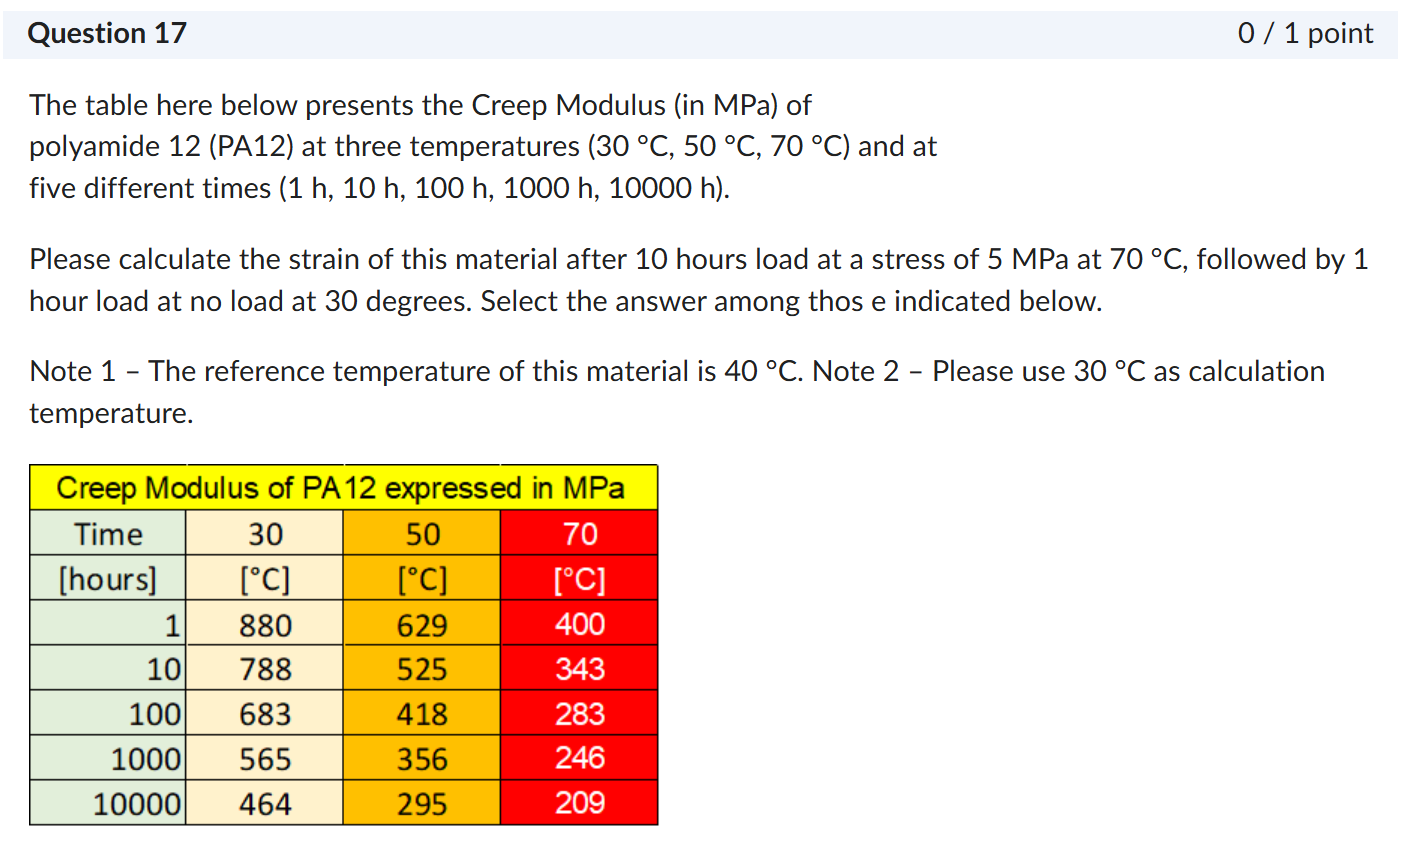

In [2]:
# ============================================================
# CONVERTING CREEP MODULUS [MPa]
# TO COMPLIANCE [1/Pa]
# ============================================================

import pandas as pd

# Original creep modulus table [MPa]
E_data = {
    "TIME [hour]": [1, 10, 100, 1000, 10000],
    30: [880, 788, 683, 565, 464],
    50: [629, 525, 418, 356, 295],
    70: [400, 343, 283, 246, 209],
}

df_E = pd.DataFrame(E_data)

# ============================================================
# CONVERT E -> J
# ============================================================

df_J = df_E.copy()

for T in [30, 50, 70]:

    df_J[T] = 1 / (df_E[T] * 1e6)

# ============================================================
# PRINT RESULTS
# ============================================================

print(df_J)

   TIME [hour]            30            50            70
0            1  1.136364e-09  1.589825e-09  2.500000e-09
1           10  1.269036e-09  1.904762e-09  2.915452e-09
2          100  1.464129e-09  2.392344e-09  3.533569e-09
3         1000  1.769912e-09  2.808989e-09  4.065041e-09
4        10000  2.155172e-09  3.389831e-09  4.784689e-09


In [3]:
import math

df = df_J

# ============================================================
# REFERENCE TEMPERATURE
# ============================================================

T_ref = 40  # °C

# ============================================================
# WLF SHIFT FACTOR FUNCTION
# ============================================================

def shift_factor(T, T_ref):

    delta_T = T - T_ref

    log10_aT = (
        -(8.86 * delta_T)
        /
        (101.6 + delta_T)
    )

    # DTU-style rounding
    log10_aT = round(log10_aT, 4)

    aT = 10 ** log10_aT

    # DTU-style rounding
    aT = round(aT, 5)

    return log10_aT, aT

# ============================================================
# LOGARITHMIC INTERPOLATION FUNCTION
# ============================================================

def interpolate_compliance(t, temperature, df):

    time_values = df["TIME [hour]"].values
    J_values = df[temperature].values

    # --------------------------------------------------------
    # EXACT MATCH
    # --------------------------------------------------------

    if any(abs(t - tv) < 1e-9 for tv in time_values):

        idx = min(
            range(len(time_values)),
            key=lambda i: abs(time_values[i] - t)
        )

        J_exact = J_values[idx]

        print("Exact table value used")
        print(f"Time = {t:.3f} h")
        print(f"Compliance = {J_exact:.3e}\n")

        return J_exact

    # --------------------------------------------------------
    # FIND INTERPOLATION REGION
    # --------------------------------------------------------

    for i in range(len(time_values)-1):

        if time_values[i] <= t <= time_values[i+1]:

            t1 = time_values[i]
            t2 = time_values[i+1]

            J1 = J_values[i]
            J2 = J_values[i+1]

            # ------------------------------------------------
            # DTU-STYLE ROUNDING
            # ------------------------------------------------

            log_t = round(math.log10(t), 4)
            log_t1 = round(math.log10(t1), 4)
            log_t2 = round(math.log10(t2), 4)

            # ------------------------------------------------
            # LOG INTERPOLATION
            # ------------------------------------------------

            J_interp = (
                J1
                +
                (J2 - J1)
                *
                (
                    (log_t - log_t1)
                    /
                    (log_t2 - log_t1)
                )
            )

            # DTU-style rounding
            J_interp = round(J_interp, 13)

            # ------------------------------------------------
            # PRINT INTERPOLATION DETAILS
            # ------------------------------------------------

            print("Interpolation details:")
            print(f"Reference temperature table = {temperature} °C")

            print(
                f"Interpolating between "
                f"{t1} h and {t2} h"
            )

            print(f"J1 = {J1:.3e}")
            print(f"J2 = {J2:.3e}")

            print(f"log10(t) = {log_t:.4f}")
            print(f"log10(t1) = {log_t1:.4f}")
            print(f"log10(t2) = {log_t2:.4f}")

            print(
                f"Interpolated J = "
                f"{J_interp:.3e}\n"
            )

            return J_interp

    raise ValueError(
        f"Shifted time {t:.3f} h outside table range"
    )

# ============================================================
# BOLTZMANN SUPERPOSITION FUNCTION
# ============================================================

def boltzmann_strain_temperature(
    sigma_changes,
    load_times,
    temperatures,
    t_total,
    df
):

    epsilon = 0

    print("================================================")
    print("BOLTZMANN SUPERPOSITION CALCULATION")
    print("================================================\n")

    for sigma, tau, T in zip(
        sigma_changes,
        load_times,
        temperatures
    ):

        if t_total > tau:

            # ------------------------------------------------
            # REAL TIME DIFFERENCE
            # ------------------------------------------------

            delta_t_real = t_total - tau

            # ------------------------------------------------
            # SHIFT FACTOR
            # ------------------------------------------------

            log10_aT, aT = shift_factor(
                T,
                T_ref
            )

            # ------------------------------------------------
            # SHIFTED TIME
            # ------------------------------------------------

            delta_t_shifted = (
                delta_t_real / aT
            )

            # DTU-style rounding
            delta_t_shifted = round(
                delta_t_shifted,
                3
            )

            print("------------------------------------------------")
            print(f"Load event at t = {tau} h")

            print(f"Temperature T = {T} °C")
            print(f"Reference temperature = {T_ref} °C")

            print(
                f"ΔT = {T - T_ref} °C"
            )

            print(
                f"log10(aT) = {log10_aT:.4f}"
            )

            print(
                f"aT = {aT:.5f}"
            )

            print(
                f"Stress change σ = "
                f"{sigma:.3e} Pa"
            )

            print(
                f"Real time difference = "
                f"{delta_t_real:.3f} h"
            )

            print(
                f"Shifted time = "
                f"{delta_t_shifted:.3f} h\n"
            )

            # ------------------------------------------------
            # COMPLIANCE AT REFERENCE TEMPERATURE
            # ------------------------------------------------

            J = interpolate_compliance(
                delta_t_shifted,
                T_ref,
                df
            )

            # ------------------------------------------------
            # STRAIN CONTRIBUTION
            # ------------------------------------------------

            contribution = sigma * J

            # DTU-style rounding
            contribution = round(
                contribution,
                6
            )

            print(
                f"Strain contribution = "
                f"{contribution:.6e}"
            )

            print("------------------------------------------------\n")

            epsilon += contribution

    return epsilon

# ============================================================
# TYPE IN LOAD HISTORY !HERE!
# ============================================================

# Stress changes [Pa]
sigma_changes = [
    5e6,     # Apply +5 MPa
    -5e6,    # Remove 5 MPa
]

# Times where stress changes occur [h]
load_times = [
    0,
    10,
]

# Temperature for EACH load event [°C]
temperatures = [
    70,
    30,
]

# Total evaluation time [h]
t_total = 11

# ============================================================
# CALCULATE STRAIN
# ============================================================

epsilon = boltzmann_strain_temperature(
    sigma_changes,
    load_times,
    temperatures,
    t_total,
    df
)

# ============================================================
# RESULTS
# ============================================================

print("================================================")
print("FINAL RESULTS")
print("================================================")

print(f"Total strain = {epsilon:.6e}")

print(
    f"Total strain percent = "
    f"{epsilon*100:.6f} %"
)

BOLTZMANN SUPERPOSITION CALCULATION

------------------------------------------------
Load event at t = 0 h
Temperature T = 70 °C
Reference temperature = 40 °C
ΔT = 30 °C
log10(aT) = -2.0198
aT = 0.00955
Stress change σ = 5.000e+06 Pa
Real time difference = 11.000 h
Shifted time = 1151.832 h



KeyError: 40

## **2023 Question 18**

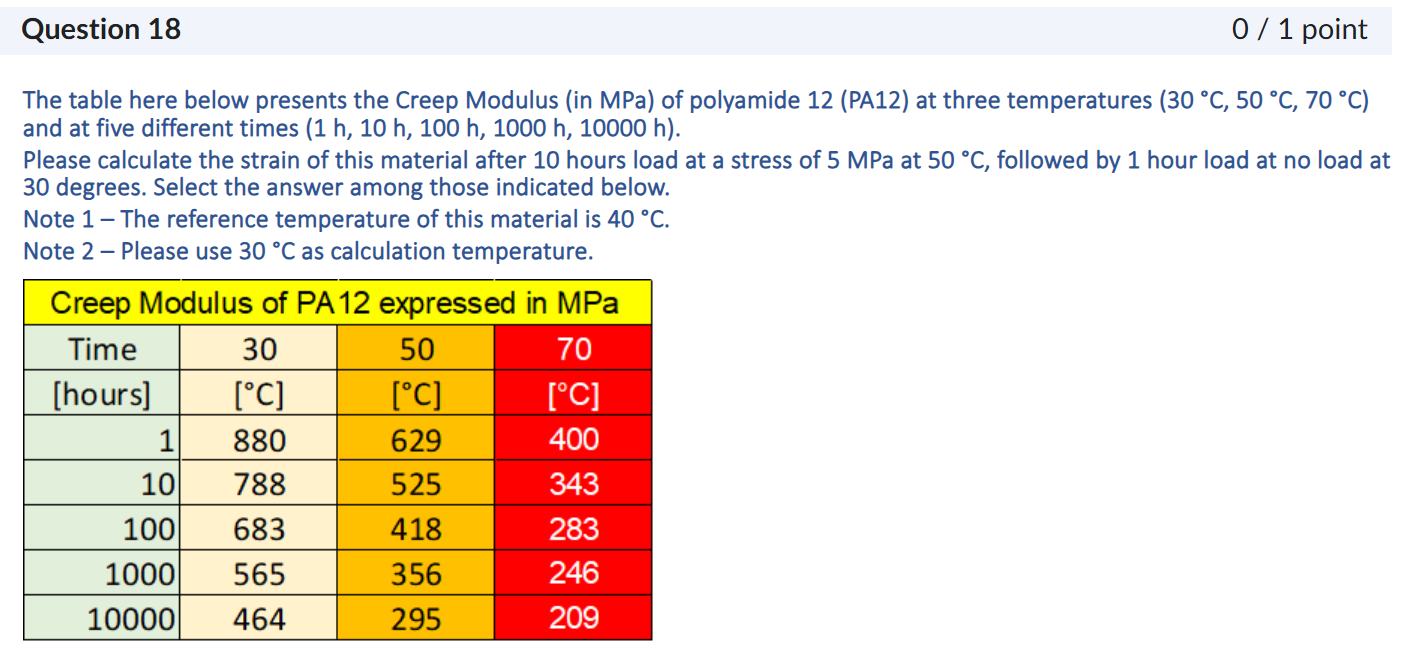

In [2]:
# ============================================================
# CONVERTING CREEP MODULUS [MPa]
# TO COMPLIANCE [1/Pa]
# ============================================================

import pandas as pd

# Original creep modulus table [MPa]
E_data = {
    "TIME [hour]": [1, 10, 100, 1000, 10000],
    30: [880, 788, 683, 565, 464],
    50: [629, 525, 418, 356, 295],
    70: [400, 343, 283, 246, 209],
}

df_E = pd.DataFrame(E_data)

# ============================================================
# CONVERT E -> J
# ============================================================

df_J = df_E.copy()

for T in [30, 50, 70]:

    df_J[T] = 1 / (df_E[T] * 1e6)

# ============================================================
# PRINT RESULTS
# ============================================================

print(df_J)

   TIME [hour]            30            50            70
0            1  1.136364e-09  1.589825e-09  2.500000e-09
1           10  1.269036e-09  1.904762e-09  2.915452e-09
2          100  1.464129e-09  2.392344e-09  3.533569e-09
3         1000  1.769912e-09  2.808989e-09  4.065041e-09
4        10000  2.155172e-09  3.389831e-09  4.784689e-09


In [3]:
import math

df = df_J

# ============================================================
# REFERENCE TEMPERATURE
# ============================================================

T_ref = 30  # °C

# ============================================================
# WLF SHIFT FACTOR FUNCTION
# ============================================================

def shift_factor(T, T_ref):

    delta_T = T - T_ref

    log10_aT = (
        -(8.86 * delta_T)
        /
        (101.6 + delta_T)
    )

    # DTU-style rounding
    log10_aT = round(log10_aT, 4)

    aT = 10 ** log10_aT

    # DTU-style rounding
    aT = round(aT, 5)

    return log10_aT, aT

# ============================================================
# LOGARITHMIC INTERPOLATION FUNCTION
# ============================================================

def interpolate_compliance(t, temperature, df):

    time_values = df["TIME [hour]"].values
    J_values = df[temperature].values

    # --------------------------------------------------------
    # EXACT MATCH
    # --------------------------------------------------------

    if any(abs(t - tv) < 1e-9 for tv in time_values):

        idx = min(
            range(len(time_values)),
            key=lambda i: abs(time_values[i] - t)
        )

        J_exact = J_values[idx]

        print("Exact table value used")
        print(f"Time = {t:.3f} h")
        print(f"Compliance = {J_exact:.3e}\n")

        return J_exact

    # --------------------------------------------------------
    # FIND INTERPOLATION REGION
    # --------------------------------------------------------

    for i in range(len(time_values)-1):

        if time_values[i] <= t <= time_values[i+1]:

            t1 = time_values[i]
            t2 = time_values[i+1]

            J1 = J_values[i]
            J2 = J_values[i+1]

            # ------------------------------------------------
            # DTU-STYLE ROUNDING
            # ------------------------------------------------

            log_t = round(math.log10(t), 4)
            log_t1 = round(math.log10(t1), 4)
            log_t2 = round(math.log10(t2), 4)

            # ------------------------------------------------
            # LOG INTERPOLATION
            # ------------------------------------------------

            J_interp = (
                J1
                +
                (J2 - J1)
                *
                (
                    (log_t - log_t1)
                    /
                    (log_t2 - log_t1)
                )
            )

            # DTU-style rounding
            J_interp = round(J_interp, 13)

            # ------------------------------------------------
            # PRINT INTERPOLATION DETAILS
            # ------------------------------------------------

            print("Interpolation details:")
            print(f"Reference temperature table = {temperature} °C")

            print(
                f"Interpolating between "
                f"{t1} h and {t2} h"
            )

            print(f"J1 = {J1:.3e}")
            print(f"J2 = {J2:.3e}")

            print(f"log10(t) = {log_t:.4f}")
            print(f"log10(t1) = {log_t1:.4f}")
            print(f"log10(t2) = {log_t2:.4f}")

            print(
                f"Interpolated J = "
                f"{J_interp:.3e}\n"
            )

            return J_interp

    raise ValueError(
        f"Shifted time {t:.3f} h outside table range"
    )

# ============================================================
# BOLTZMANN SUPERPOSITION FUNCTION
# ============================================================

def boltzmann_strain_temperature(
    sigma_changes,
    load_times,
    temperatures,
    t_total,
    df
):

    epsilon = 0

    print("================================================")
    print("BOLTZMANN SUPERPOSITION CALCULATION")
    print("================================================\n")

    for sigma, tau, T in zip(
        sigma_changes,
        load_times,
        temperatures
    ):

        if t_total > tau:

            # ------------------------------------------------
            # REAL TIME DIFFERENCE
            # ------------------------------------------------

            delta_t_real = t_total - tau

            # ------------------------------------------------
            # SHIFT FACTOR
            # ------------------------------------------------

            log10_aT, aT = shift_factor(
                T,
                T_ref
            )

            # ------------------------------------------------
            # SHIFTED TIME
            # ------------------------------------------------

            delta_t_shifted = (
                delta_t_real / aT
            )

            # DTU-style rounding
            delta_t_shifted = round(
                delta_t_shifted,
                3
            )

            print("------------------------------------------------")
            print(f"Load event at t = {tau} h")

            print(f"Temperature T = {T} °C")
            print(f"Reference temperature = {T_ref} °C")

            print(
                f"ΔT = {T - T_ref} °C"
            )

            print(
                f"log10(aT) = {log10_aT:.4f}"
            )

            print(
                f"aT = {aT:.5f}"
            )

            print(
                f"Stress change σ = "
                f"{sigma:.3e} Pa"
            )

            print(
                f"Real time difference = "
                f"{delta_t_real:.3f} h"
            )

            print(
                f"Shifted time = "
                f"{delta_t_shifted:.3f} h\n"
            )

            # ------------------------------------------------
            # COMPLIANCE AT REFERENCE TEMPERATURE
            # ------------------------------------------------

            J = interpolate_compliance(
                delta_t_shifted,
                T_ref,
                df
            )

            # ------------------------------------------------
            # STRAIN CONTRIBUTION
            # ------------------------------------------------

            contribution = sigma * J

            # DTU-style rounding
            contribution = round(
                contribution,
                6
            )

            print(
                f"Strain contribution = "
                f"{contribution:.6e}"
            )

            print("------------------------------------------------\n")

            epsilon += contribution

    return epsilon

# ============================================================
# TYPE IN LOAD HISTORY !HERE!
# ============================================================

# Stress changes [Pa]
sigma_changes = [
    5e6,     # Apply +5 MPa
    -5e6,    # Remove 5 MPa
]

# Times where stress changes occur [h]
load_times = [
    0,
    10,
]

# Temperature for EACH load event [°C]
temperatures = [
    50,
    30,
]

# Total evaluation time [h]
t_total = 11

# ============================================================
# CALCULATE STRAIN
# ============================================================

epsilon = boltzmann_strain_temperature(
    sigma_changes,
    load_times,
    temperatures,
    t_total,
    df
)

# ============================================================
# RESULTS
# ============================================================

print("================================================")
print("FINAL RESULTS")
print("================================================")

print(f"Total strain = {epsilon:.6e}")

print(
    f"Total strain percent = "
    f"{epsilon*100:.6f} %"
)

BOLTZMANN SUPERPOSITION CALCULATION

------------------------------------------------
Load event at t = 0 h
Temperature T = 50 °C
Reference temperature = 30 °C
ΔT = 20 °C
log10(aT) = -1.4572
aT = 0.03490
Stress change σ = 5.000e+06 Pa
Real time difference = 11.000 h
Shifted time = 315.186 h

Interpolation details:
Reference temperature table = 30 °C
Interpolating between 100 h and 1000 h
J1 = 1.464e-09
J2 = 1.770e-09
log10(t) = 2.4986
log10(t1) = 2.0000
log10(t2) = 3.0000
Interpolated J = 1.617e-09

Strain contribution = 8.083000e-03
------------------------------------------------

------------------------------------------------
Load event at t = 10 h
Temperature T = 30 °C
Reference temperature = 30 °C
ΔT = 0 °C
log10(aT) = -0.0000
aT = 1.00000
Stress change σ = -5.000e+06 Pa
Real time difference = 1.000 h
Shifted time = 1.000 h

Exact table value used
Time = 1.000 h
Compliance = 1.136e-09

Strain contribution = -5.682000e-03
------------------------------------------------

FINAL RE

# **2023 Question 19**

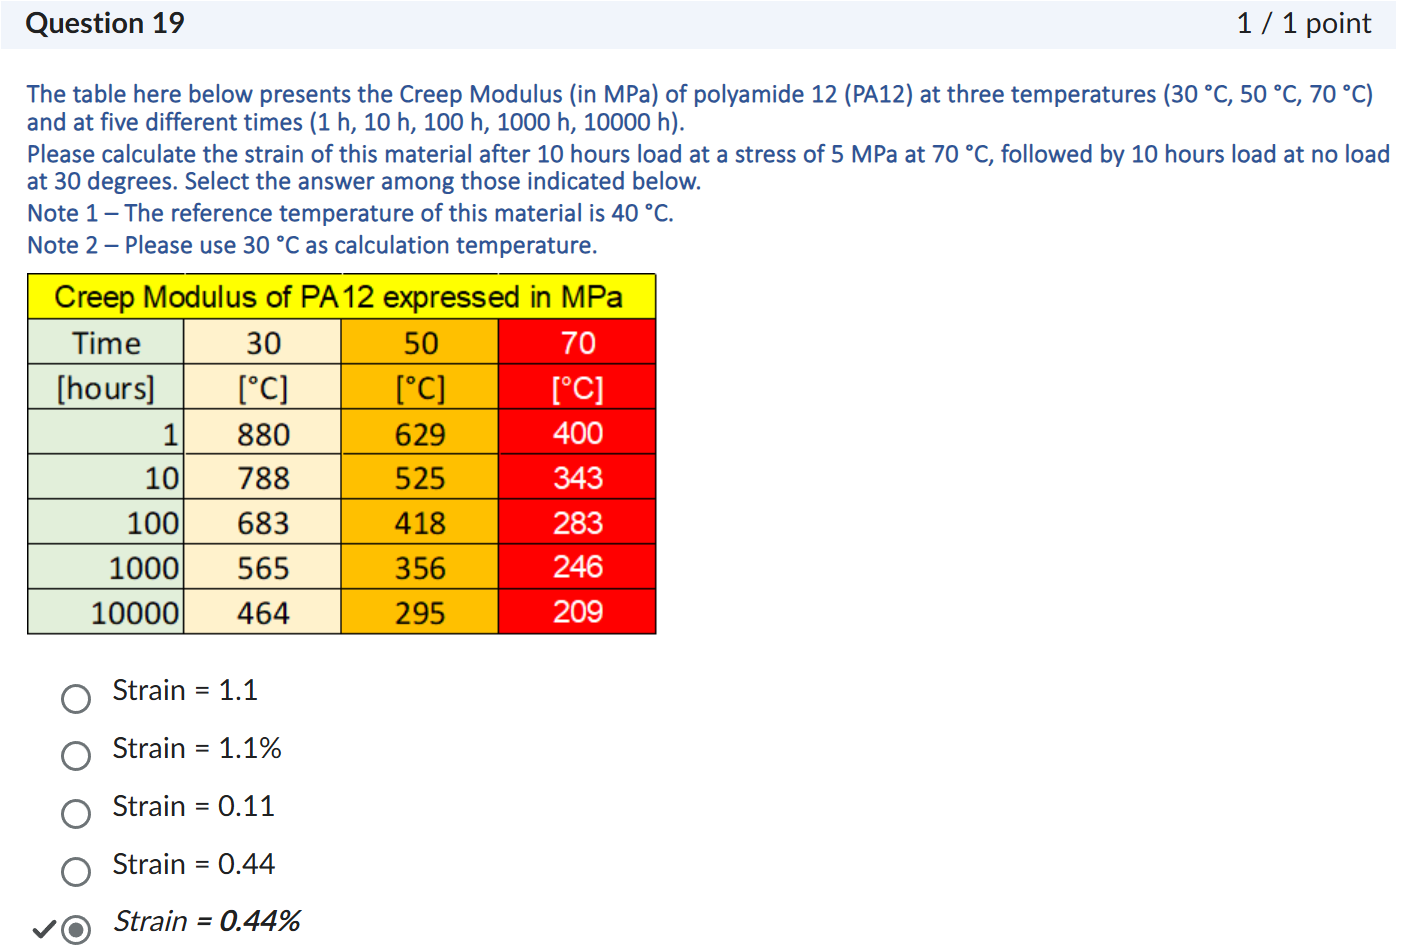

In [1]:
# ============================================================
# CONVERTING CREEP MODULUS [MPa]
# TO COMPLIANCE [1/Pa]
# ============================================================

import pandas as pd

# Original creep modulus table [MPa]
E_data = {
    "TIME [hour]": [1, 10, 100, 1000, 10000],
    30: [880, 788, 683, 565, 464],
    50: [629, 525, 418, 356, 295],
    70: [400, 343, 283, 246, 209],
}

df_E = pd.DataFrame(E_data)

# ============================================================
# CONVERT E -> J
# ============================================================

df_J = df_E.copy()

for T in [30, 50, 70]:

    df_J[T] = 1 / (df_E[T] * 1e6)

# ============================================================
# PRINT RESULTS
# ============================================================

print(df_J)

   TIME [hour]            30            50            70
0            1  1.136364e-09  1.589825e-09  2.500000e-09
1           10  1.269036e-09  1.904762e-09  2.915452e-09
2          100  1.464129e-09  2.392344e-09  3.533569e-09
3         1000  1.769912e-09  2.808989e-09  4.065041e-09
4        10000  2.155172e-09  3.389831e-09  4.784689e-09


In [2]:
import math

df = df_J

# ============================================================
# REFERENCE TEMPERATURE
# ============================================================

T_ref = 30  # °C

# ============================================================
# WLF SHIFT FACTOR FUNCTION
# ============================================================

def shift_factor(T, T_ref):

    delta_T = T - T_ref

    log10_aT = (
        -(8.86 * delta_T)
        /
        (101.6 + delta_T)
    )

    # DTU-style rounding
    log10_aT = round(log10_aT, 4)

    aT = 10 ** log10_aT

    # DTU-style rounding
    aT = round(aT, 5)

    return log10_aT, aT

# ============================================================
# LOGARITHMIC INTERPOLATION FUNCTION
# ============================================================

def interpolate_compliance(t, temperature, df):

    time_values = df["TIME [hour]"].values
    J_values = df[temperature].values

    # --------------------------------------------------------
    # EXACT MATCH
    # --------------------------------------------------------

    if any(abs(t - tv) < 1e-9 for tv in time_values):

        idx = min(
            range(len(time_values)),
            key=lambda i: abs(time_values[i] - t)
        )

        J_exact = J_values[idx]

        print("Exact table value used")
        print(f"Time = {t:.3f} h")
        print(f"Compliance = {J_exact:.3e}\n")

        return J_exact

    # --------------------------------------------------------
    # FIND INTERPOLATION REGION
    # --------------------------------------------------------

    for i in range(len(time_values)-1):

        if time_values[i] <= t <= time_values[i+1]:

            t1 = time_values[i]
            t2 = time_values[i+1]

            J1 = J_values[i]
            J2 = J_values[i+1]

            # ------------------------------------------------
            # DTU-STYLE ROUNDING
            # ------------------------------------------------

            log_t = round(math.log10(t), 4)
            log_t1 = round(math.log10(t1), 4)
            log_t2 = round(math.log10(t2), 4)

            # ------------------------------------------------
            # LOG INTERPOLATION
            # ------------------------------------------------

            J_interp = (
                J1
                +
                (J2 - J1)
                *
                (
                    (log_t - log_t1)
                    /
                    (log_t2 - log_t1)
                )
            )

            # DTU-style rounding
            J_interp = round(J_interp, 13)

            # ------------------------------------------------
            # PRINT INTERPOLATION DETAILS
            # ------------------------------------------------

            print("Interpolation details:")
            print(f"Reference temperature table = {temperature} °C")

            print(
                f"Interpolating between "
                f"{t1} h and {t2} h"
            )

            print(f"J1 = {J1:.3e}")
            print(f"J2 = {J2:.3e}")

            print(f"log10(t) = {log_t:.4f}")
            print(f"log10(t1) = {log_t1:.4f}")
            print(f"log10(t2) = {log_t2:.4f}")

            print(
                f"Interpolated J = "
                f"{J_interp:.3e}\n"
            )

            return J_interp

    raise ValueError(
        f"Shifted time {t:.3f} h outside table range"
    )

# ============================================================
# BOLTZMANN SUPERPOSITION FUNCTION
# ============================================================

def boltzmann_strain_temperature(
    sigma_changes,
    load_times,
    temperatures,
    t_total,
    df
):

    epsilon = 0

    print("================================================")
    print("BOLTZMANN SUPERPOSITION CALCULATION")
    print("================================================\n")

    for sigma, tau, T in zip(
        sigma_changes,
        load_times,
        temperatures
    ):

        if t_total > tau:

            # ------------------------------------------------
            # REAL TIME DIFFERENCE
            # ------------------------------------------------

            delta_t_real = t_total - tau

            # ------------------------------------------------
            # SHIFT FACTOR
            # ------------------------------------------------

            log10_aT, aT = shift_factor(
                T,
                T_ref
            )

            # ------------------------------------------------
            # SHIFTED TIME
            # ------------------------------------------------

            delta_t_shifted = (
                delta_t_real / aT
            )

            # DTU-style rounding
            delta_t_shifted = round(
                delta_t_shifted,
                3
            )

            print("------------------------------------------------")
            print(f"Load event at t = {tau} h")

            print(f"Temperature T = {T} °C")
            print(f"Reference temperature = {T_ref} °C")

            print(
                f"ΔT = {T - T_ref} °C"
            )

            print(
                f"log10(aT) = {log10_aT:.4f}"
            )

            print(
                f"aT = {aT:.5f}"
            )

            print(
                f"Stress change σ = "
                f"{sigma:.3e} Pa"
            )

            print(
                f"Real time difference = "
                f"{delta_t_real:.3f} h"
            )

            print(
                f"Shifted time = "
                f"{delta_t_shifted:.3f} h\n"
            )

            # ------------------------------------------------
            # COMPLIANCE AT REFERENCE TEMPERATURE
            # ------------------------------------------------

            J = interpolate_compliance(
                delta_t_shifted,
                T_ref,
                df
            )

            # ------------------------------------------------
            # STRAIN CONTRIBUTION
            # ------------------------------------------------

            contribution = sigma * J

            # DTU-style rounding
            contribution = round(
                contribution,
                6
            )

            print(
                f"Strain contribution = "
                f"{contribution:.6e}"
            )

            print("------------------------------------------------\n")

            epsilon += contribution

    return epsilon

# ============================================================
# TYPE IN LOAD HISTORY !HERE!
# ============================================================

# Stress changes [Pa]
sigma_changes = [
    5e6,     # Apply +5 MPa
    -5e6,    # Remove 5 MPa
]

# Times where stress changes occur [h]
load_times = [
    0,
    10,
]

# Temperature for EACH load event [°C]
temperatures = [
    70,
    30,
]

# Total evaluation time [h]
t_total = 20

# ============================================================
# CALCULATE STRAIN
# ============================================================

epsilon = boltzmann_strain_temperature(
    sigma_changes,
    load_times,
    temperatures,
    t_total,
    df
)

# ============================================================
# RESULTS
# ============================================================

print("================================================")
print("FINAL RESULTS")
print("================================================")

print(f"Total strain = {epsilon:.6e}")

print(
    f"Total strain percent = "
    f"{epsilon*100:.6f} %"
)

BOLTZMANN SUPERPOSITION CALCULATION

------------------------------------------------
Load event at t = 0 h
Temperature T = 70 °C
Reference temperature = 30 °C
ΔT = 40 °C
log10(aT) = -2.5028
aT = 0.00314
Stress change σ = 5.000e+06 Pa
Real time difference = 20.000 h
Shifted time = 6369.427 h

Interpolation details:
Reference temperature table = 30 °C
Interpolating between 1000 h and 10000 h
J1 = 1.770e-09
J2 = 2.155e-09
log10(t) = 3.8041
log10(t1) = 3.0000
log10(t2) = 4.0000
Interpolated J = 2.080e-09

Strain contribution = 1.039900e-02
------------------------------------------------

------------------------------------------------
Load event at t = 10 h
Temperature T = 30 °C
Reference temperature = 30 °C
ΔT = 0 °C
log10(aT) = -0.0000
aT = 1.00000
Stress change σ = -5.000e+06 Pa
Real time difference = 10.000 h
Shifted time = 10.000 h

Exact table value used
Time = 10.000 h
Compliance = 1.269e-09

Strain contribution = -6.345000e-03
------------------------------------------------

FI